In [1]:
from prevo.record import SensorBase
from prevo.record.images import ImageRecording, ImageRecord
from prevo.misc import DummyLapseCamera

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# 1) Numerical sensors

See *Record.inpynb*

# 2) Record images (cameras)

## Define sensor and recordings

We assume that the user already has a source of image (e.g. a camera) and is able to interact with it in Python to get images. Here we use a dummy camera sensor that returns random images and an associate timestamp (unix time)

In [2]:
cam = DummyLapseCamera()
cam.read()

{'image': array([[130,  87, 106, ...,   0, 219, 149],
        [ 89, 237, 197, ..., 187, 101, 201],
        [  1, 188, 146, ...,  78,  29, 180],
        ...,
        [157,  15,   0, ..., 153, 166, 190],
        [255,   7, 172, ..., 139,  97,  19],
        [  3, 181,  76, ..., 156, 115,  72]], dtype=uint8),
 'timestamp': 1769525247.284213}

Similarly as above, we can subclass `SensorBase`, `ImageRecording` and `ImageRecord`. The same options are available for recordings so that we will not cover all recording and record methods again. Below, we will define two camera sensors and record them at the same time.

In [3]:
class CameraSensor(SensorBase):
    """Provide methods common to all camera sensors"""

    def __init__(self):
        super().__init__()
        self.camera = DummyLapseCamera()

    def  _read(self):
        """Here we don't want to use _get_data() but _read(), since the
        sensor provides its own timestamps."""

        # Note: here, the camera returns immediately a dict with 'image'
        # as key. If it's not the case, one should make sure here to add
        # a line to return a dict with the image array at the key 'image'
        return self.camera.read()


class Cam1(CameraSensor):
    name = 'Cam1'


class Cam2(CameraSensor):
    name = 'Cam2'


# Again, the SensorBase class provides a context manager that can be tuned if necessary
with Cam2() as camera:
    data = camera.read()
data['timestamp']

1769525249.9922376

In [4]:
class CamRecording(ImageRecording):

    def __init__(self, Sensor, **kwargs):
        """kwargs can include programs, precision options etc. (see above)"""
        super().__init__(Sensor,
                         timestamp_filename=f'{Sensor.name}_timestamps.tsv',
                         # Below: include 'filename' if you want the name of the image in the
                         # timestamp file. Any other column name must be generated as a key
                         # in the dict returned by CameraSensor._read().
                         column_names=('filename', 'timestamp',),
                         path='data',
                         **kwargs)
        self.name = Sensor.name


class CamRecord(ImageRecord):

    def __init__(self, recordings, viewer='tk'):
        """Here we do not include programs, but it's possible to pass them as well
        (e.g. to create temporal variations of fps or interval between images, etc."""
        super().__init__(recordings, path='data', viewer=viewer)

## Simple recording

Similarly to numerical recordings, one can start a camera recording with limited options directly from the recording object:

In [5]:
cam_recording = CamRecording(Cam1)
cam_recording.start(dt=1)

In [6]:
cam_recording.stop()

## Interactive, simultaneous recording with live image view

For real-time viewing of images and other interactive features including the same CLI as for numerical sensors, one needs to pass adequate viewers to the 
record object. Here we will use viewers from the cameras package. It is also possible to use your own viewer by redefining `ImageRecord.data_plot()`

In [10]:
from cameras.viewers import TkWindow, TkViewer

class CamRecordView(ImageRecord):

    @property
    def Window(self):
        return TkWindow

    @property
    def Viewer(self):
        return TkViewer

**NOTE**: Here, pressing `g` in the CLI will trigger a live view of the images. 

In [11]:
# The precise=True option can improve precision of time intervals significantly (~ms instead of ~10ms)
recordings = (
    CamRecording(Cam1, precise=True),
    CamRecording(Cam2),
)

# Here, we specify two different time intervals to read images for each camera
CamRecordView(recordings).start(dt_Cam1=0.33, dt_Cam2=0.3)

Recording started in folder /Users/olivier.vincent/Python-OV/prevo/examples


/Users/olivier.vincent/Python-OV/gittools/gittools/gittools.py:390: UserWarning: These modules have dirty git repositories: prevo
  metadata['code version'] = check_modules(
/Users/olivier.vincent/Python-OV/gittools/gittools/gittools.py:390: UserWarning: Warning: these modules are missing a tag: prevo
  metadata['code version'] = check_modules(


Graph event requested
CLI stopped
Recording Stopped


Text(0, 0.5, '$\\Delta t$ (s)')

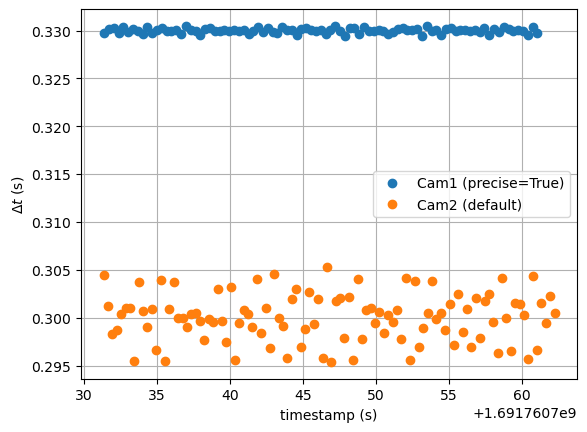

In [9]:
cam1_data = pd.read_csv('data/Cam1_timestamps.tsv', sep='\t')
cam2_data = pd.read_csv('data/Cam2_timestamps.tsv', sep='\t')

fig, ax = plt.subplots()
labels = 'Cam1 (precise=True)', 'Cam2 (default)'
all_data = cam1_data, cam2_data

for data, label in zip(all_data, labels):
    data['dt'] = data['timestamp'].diff()
    ax.plot(data['timestamp'], data['dt'], 'o', label=label)

ax.grid()
ax.legend()
ax.set_xlabel('timestamp (s)')
ax.set_ylabel(r'$\Delta t$ (s)')

# Final remarks

Everything is customizable, e.g. more specific error management, usage of personal data viewing tools (graphs, image viewers, etc.),programmable recordings, sensor properties controlled by the CLI, etc. For more information, read the docstrings in `prevo.record`, `prevo.record.numerical` and `prevo.record.images`